In [1]:
import data

from PIL import Image
import albumentations as A
import cv2

In [19]:
images_path = data.get_images_path()
samples = data.get_sorted_samples(images_path)
samples[0]

(PosixPath('/Users/shmuma/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg'),
 'cane')

In [4]:
img = cv2.imread(samples[0][0], cv2.IMREAD_COLOR_RGB)
img.shape

(225, 300, 3)

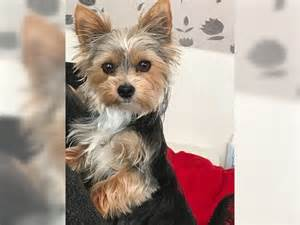

In [5]:
Image.fromarray(img)

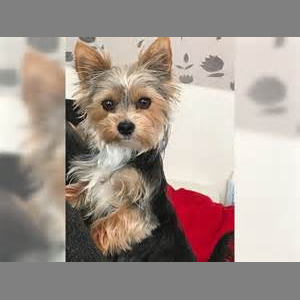

In [8]:
scaled_img = data.RESCALE_TRANSFORM(image=img)['image']
Image.fromarray(scaled_img)

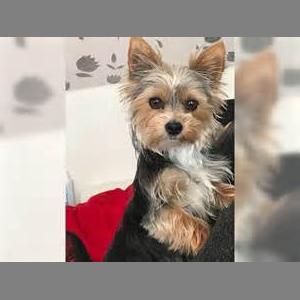

In [20]:
flip_img = A.HorizontalFlip(p=1.0)(image=scaled_img)['image']
Image.fromarray(flip_img)

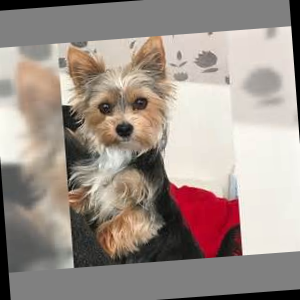

In [31]:
rot_img = A.Rotate(angle_range=(-10, 10), p=1)(image=scaled_img)['image']
Image.fromarray(rot_img)

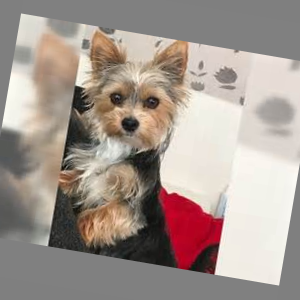

In [34]:
rot_img = A.Rotate(angle_range=(-10, 10), p=1, fill=(127, 127, 127))(image=scaled_img)['image']
Image.fromarray(rot_img)

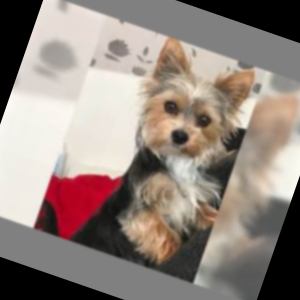

In [25]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Rotate(angle_range=(-30, 30), p=0.5),
])

res_img = augment(image=scaled_img)['image']
Image.fromarray(res_img)